<a href="https://colab.research.google.com/github/lucalomazziPolimi/Pia-Enhance-Course/blob/main/00_introduction/02_dl/DL_surrogate_blast_plate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 4 — Basics of Deep Learning
## Hands-on: Surrogate Model for a Blast-Loaded Plate

**Deep Learning–Driven Design under Dynamic Loads**  
Dr. L. Lomazzi — PoliMi / NTNU

---

### What you will build

A surrogate model that maps four structural and blast parameters directly to the **permanent midpoint deflection** of a fully-clamped steel plate — without running a single FEM simulation.

The dataset is generated analytically from a validated SDOF blast model (Biggs, 1964; UFC 3-340-02 lineage), with realistic multiplicative noise mimicking FEM mesh variability.

### Inputs

| Symbol | Description | Range | Unit |
|--------|-------------|-------|------|
| $h$ | Plate thickness | 5 – 25 | mm |
| $L$ | Plate span | 0.4 – 1.5 | m |
| $P_0$ | Peak overpressure | 50 – 400 | kPa |
| $t_d$ | Positive phase duration | 2 – 50 | ms |

### Output

| Symbol | Description | Unit |
|--------|-------------|------|
| $u_{res}$ | Permanent midpoint deflection | mm |

### Notebook structure

0. Imports and reproducibility
1. Dataset generation (analytical SDOF model)
2. Exploratory analysis and data pipeline
3. MLP in PyTorch
4. Training and diagnostics
5. **Your turn** — open experiments

> **Prerequisite**: review the async slide deck (Modules D1–D6) before this session.

---
## 0 — Imports and reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version : {torch.__version__}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device          : {DEVICE}")

PyTorch version : 2.10.0+cpu
Device          : cpu


---
## 1 — Dataset generation

### Physical model

**Setup.** Fully-clamped square steel plate under a triangular blast pulse. The plate is reduced to an equivalent SDOF system (Biggs, 1964).

**Flexural rigidity and equivalent SDOF stiffness:**

$$D = \frac{E h^3}{12(1-\nu^2)}, \qquad K_{eq} = \frac{192\, D}{L^2} \cdot KLM \cdot L^2$$

with $KLM = 0.45$ (load-mass transformation factor, clamped plate, uniform load).

**Natural period:**

$$\omega_n = \frac{\pi^2}{L^2}\sqrt{\frac{D}{\rho h}}, \qquad T_n = \frac{2\pi}{\omega_n}$$

**Dynamic load factor** for a triangular pulse (Biggs, 1964):

$$\text{DLF} = \begin{cases} 2\pi\, t_d / T_n & t_d/T_n < 0.4 \quad\text{(impulsive)} \\[4pt] 2\!\left(1 - \dfrac{T_n}{2\pi t_d}\sin\dfrac{2\pi t_d}{T_n}\right) & \text{otherwise} \quad\text{(dynamic/quasi-static)} \end{cases}$$

**Elastic peak deflection:**

$$u_{el} = \text{DLF} \cdot \frac{P_0 L^2}{K_{eq}}$$

**Yield deflection and ductility:**

$$M_p = \frac{\sigma_y h^2}{4}, \quad P_y = \frac{16 M_p}{L^2}, \quad u_y = \frac{P_y L^2}{K_{eq}}, \quad \mu = \frac{u_{el}}{u_y}$$

**Permanent deflection** (energy-balance SDOF):

$$u_{res} = \begin{cases} 0 & \mu \leq 1 \\[4pt] u_y \!\left(\mu - \tfrac{1}{2} - \tfrac{1}{2\mu}\right) & \mu > 1 \end{cases}$$

**Noise** (multiplicative, mimicking FEM mesh variability):
$$u_{res}^{obs} = u_{res}\,(1 + \varepsilon), \quad \varepsilon\sim\mathcal{N}(0,\,0.05^2)$$

**Validity filter:** cases with ductility $\mu > 10$ or $u_{res}/L > 0.25$ are discarded (collapse territory in blast design practice).

In [2]:
# ── Fixed material parameters (structural steel) ──────────────────────────────
E      = 210e9    # Young's modulus  [Pa]
nu     = 0.3      # Poisson's ratio  [-]
rho    = 7850.0   # Density          [kg/m³]
sig_y  = 250e6    # Yield stress     [Pa]
KLM    = 0.45     # Load-mass factor [-]  (clamped plate, uniform load)
NOISE  = 0.05     # Multiplicative noise std
EPS    = 1e-6     # Log-transform offset


def generate_dataset(N_target: int = 2500, seed: int = 42) -> dict:
    """
    Generate N_target valid samples from the analytical SDOF blast-plate model.

    Oversamples to N_target*2 then filters for physical validity:
      - ductility mu <= 10  (beyond = collapse)
      - u_res / L  < 0.25   (25% span = practical limit)

    Returns dict with keys:
        h, L, P0, td   : inputs  (SI units)
        u_res          : permanent deflection  [m]  (with noise)
        mu, td_Tn      : derived quantities for inspection / split
    """
    rng = np.random.default_rng(seed)
    N = N_target * 2   # oversample, then filter

    # ── Sampling ─────────────────────────────────────────────────────────
    h  = rng.uniform(5e-3,  25e-3, N)   # plate thickness  [m]
    L  = rng.uniform(0.4,   1.5,   N)   # plate span       [m]
    P0 = rng.uniform(50e3,  400e3, N)   # peak pressure    [Pa]
    td = rng.uniform(2e-3,  50e-3, N)   # load duration    [s]

    # ── Plate mechanics ───────────────────────────────────────────────────
    D      = E * h**3 / (12 * (1 - nu**2))
    K_eq   = 192 * D / L**2 * KLM * L**2   # [N/m]

    # ── Natural period ────────────────────────────────────────────────────
    omega_n = (np.pi**2 / L**2) * np.sqrt(D / (rho * h))
    Tn      = 2 * np.pi / omega_n
    ratio   = td / Tn

    # ── Dynamic load factor (Biggs, 1964) ─────────────────────────────────
    DLF = np.where(
        ratio < 0.4,
        2 * np.pi * ratio,
        2 * (1 - Tn / (2 * np.pi * td) * np.sin(2 * np.pi * ratio))
    )
    DLF = np.clip(DLF, 0.0, 2.0)

    # ── Elastic peak deflection ───────────────────────────────────────────
    u_el = DLF * P0 * L**2 / K_eq

    # ── Yield quantities and ductility ────────────────────────────────────
    Mp  = sig_y * h**2 / 4
    u_y = 16 * Mp / L**2 * L**2 / K_eq
    mu  = u_el / u_y

    # ── Residual deflection (energy-balance SDOF) ─────────────────────────
    u_res = np.where(mu <= 1.0, 0.0, u_y * (mu - 0.5 - 0.5 / mu))

    # ── Physical validity filter ──────────────────────────────────────────
    valid = (mu <= 10.0) & (u_res / L < 0.25)

    # ── Multiplicative noise (yielded cases only) ─────────────────────────
    eps       = rng.normal(0, NOISE, N)
    u_res_obs = np.where(mu > 1.0, u_res * (1 + eps), 0.0)
    u_res_obs = np.clip(u_res_obs, 0.0, None)

    # ── Trim to N_target ─────────────────────────────────────────────────
    idx = np.where(valid)[0][:N_target]

    return {
        'h':     h[idx],
        'L':     L[idx],
        'P0':    P0[idx],
        'td':    td[idx],
        'u_res': u_res_obs[idx],
        'mu':    mu[idx],
        'td_Tn': ratio[idx]
    }


data = generate_dataset(N_target=2500)

print("Dataset summary")
print(f"  N                : {len(data['u_res'])}")
print(f"  Elastic (mu<=1)  : {(data['mu']<=1).sum():4d}  ({100*(data['mu']<=1).mean():.1f}%)")
print(f"  Yielded (mu> 1)  : {(data['mu']> 1).sum():4d}  ({100*(data['mu']> 1).mean():.1f}%)")
print(f"  mu range         : {data['mu'].min():.2f} – {data['mu'].max():.2f}")
print(f"  u_res range      : {data['u_res'].min()*1e3:.3f} – {data['u_res'].max()*1e3:.1f} mm")
print(f"  td/Tn range      : {data['td_Tn'].min():.3f} – {data['td_Tn'].max():.2f}")

Dataset summary
  N                : 2500
  Elastic (mu<=1)  : 1164  (46.6%)
  Yielded (mu> 1)  : 1336  (53.4%)
  mu range         : 0.05 – 7.75
  u_res range      : 0.000 – 365.3 mm
  td/Tn range      : 0.024 – 15.53


---
## 2 — Exploratory analysis and data pipeline

Before training anything, always look at your data. Three questions to answer:
1. What does the output distribution look like — and does it need a transform?
2. Do the inputs correlate with the output in a physically sensible way?
3. How should we split, and what preprocessing is needed?

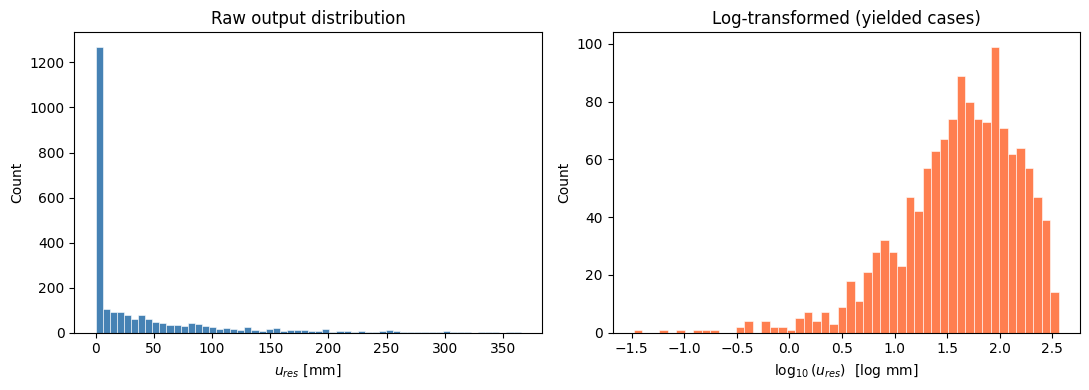

Output std (raw)     : 65.0 mm
Output std (log10)   : 0.572  (much tighter)

Conclusion: the output spans ~3 decades. The log-transform compresses
this range and makes gradient magnitudes more uniform → use log10(u_res + ε).


In [3]:
# ── 2.1  Output distribution ──────────────────────────────────────────────────
u_mm = data['u_res'] * 1e3  # [mm]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(u_mm, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('$u_{res}$ [mm]')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw output distribution')

u_yielded = u_mm[u_mm > 0]
axes[1].hist(np.log10(u_yielded), bins=50, color='coral', edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('$\\log_{10}(u_{res})$  [log mm]')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-transformed (yielded cases)')

plt.tight_layout()
plt.show()

print(f"Output std (raw)     : {u_mm.std():.1f} mm")
print(f"Output std (log10)   : {np.log10(u_mm[u_mm>0]).std():.3f}  (much tighter)")
print()
print("Conclusion: the output spans ~3 decades. The log-transform compresses")
print("this range and makes gradient magnitudes more uniform → use log10(u_res + ε).")

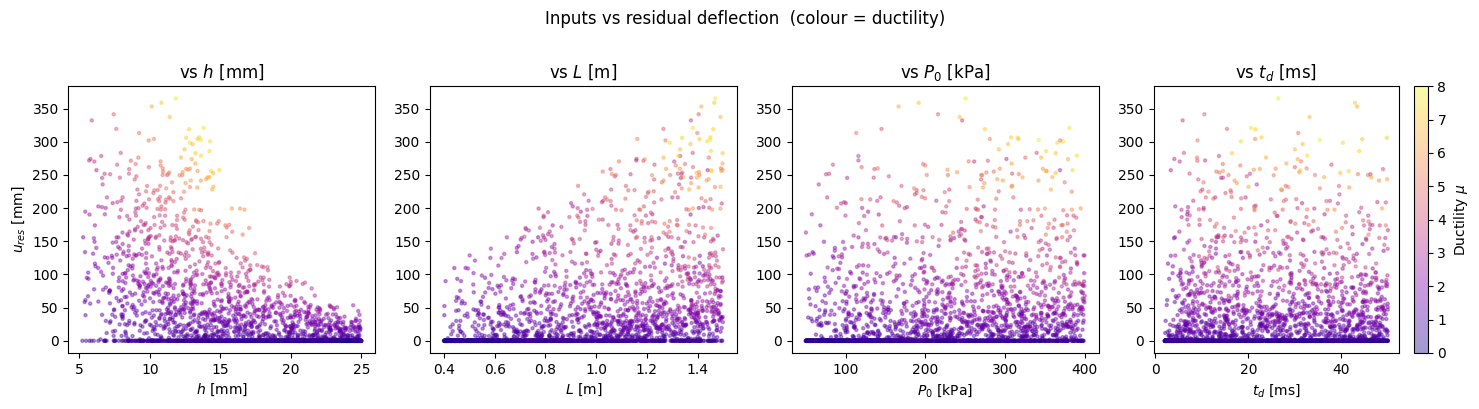

Physical sanity checks (always do this before training):
  h  ↑  →  u_res ↓  (thicker = stiffer and stronger)    ✓
  L  ↑  →  u_res ↑  (larger span = more flexible)        ✓
  P0 ↑  →  u_res ↑  (more load = more damage)            ✓
  td : mixed — interacts with Tn via the DLF regime change ✓


In [4]:
# ── 2.2  Input–output scatter plots ──────────────────────────────────────────
labels   = ['$h$ [mm]', '$L$ [m]', '$P_0$ [kPa]', '$t_d$ [ms]']
X_plot   = np.stack([
    data['h'] * 1e3,
    data['L'],
    data['P0'] * 1e-3,
    data['td'] * 1e3
], axis=1)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for i, ax in enumerate(axes):
    sc = ax.scatter(X_plot[:, i], u_mm, c=data['mu'], cmap='plasma',
                    s=5, alpha=0.4, vmin=0, vmax=8)
    ax.set_xlabel(labels[i])
    if i == 0: ax.set_ylabel('$u_{res}$ [mm]')
    ax.set_title(f'vs {labels[i]}')
plt.colorbar(sc, ax=axes[-1], label='Ductility $\\mu$')
plt.suptitle('Inputs vs residual deflection  (colour = ductility)', y=1.01)
plt.tight_layout()
plt.show()

print("Physical sanity checks (always do this before training):")
print("  h  ↑  →  u_res ↓  (thicker = stiffer and stronger)    ✓")
print("  L  ↑  →  u_res ↑  (larger span = more flexible)        ✓")
print("  P0 ↑  →  u_res ↑  (more load = more damage)            ✓")
print("  td : mixed — interacts with Tn via the DLF regime change ✓")

In [5]:
# ── 2.3  Train / validation / test split ─────────────────────────────────────
#
# Random 70 / 15 / 15 split across all samples.
# Both DLF regimes are represented in every split → the model interpolates,
# not extrapolates. This is the standard setting for a surrogate evaluation.
#
# Splitting by loading regime (impulsive vs dynamic) is a harder, more
# realistic test — try it in Experiment D below.

N_total = len(data['u_res'])
rng     = np.random.default_rng(SEED)
idx_all = rng.permutation(N_total)

n_train = int(0.70 * N_total)
n_val   = int(0.15 * N_total)

idx_train = idx_all[:n_train]
idx_val   = idx_all[n_train : n_train + n_val]
idx_test  = idx_all[n_train + n_val:]

print(f"Train : {len(idx_train):4d} samples  (random 70%)")
print(f"Val   : {len(idx_val):4d} samples  (random 15%)")
print(f"Test  : {len(idx_test):4d} samples  (random 15%)")
print()
for name, idx in [('Train', idx_train), ('Val', idx_val), ('Test', idx_test)]:
    r = data['td_Tn'][idx]
    print(f"  {name}: impulsive (td/Tn<0.4) = {100*(r<0.4).mean():.1f}%  "
          f"dynamic (td/Tn>=0.4) = {100*(r>=0.4).mean():.1f}%")

Train : 1750 samples  (random 70%)
Val   :  375 samples  (random 15%)
Test  :  375 samples  (random 15%)

  Train: impulsive (td/Tn<0.4) = 19.8%  dynamic (td/Tn>=0.4) = 80.2%
  Val: impulsive (td/Tn<0.4) = 21.3%  dynamic (td/Tn>=0.4) = 78.7%
  Test: impulsive (td/Tn<0.4) = 21.9%  dynamic (td/Tn>=0.4) = 78.1%


In [6]:
# ── 2.4  Feature engineering and normalisation ────────────────────────────────
#
# Inputs  : raw SI units → z-score standardisation  (D4.1)
# Output  : log10(u_res + ε) → z-score standardisation  (D4.2)
#
# CRITICAL: fit all statistics on the TRAINING SET ONLY (D1.6).

EPS = 1e-6

X_raw = np.stack([
    data['h'],
    data['L'],
    data['P0'],
    data['td']
], axis=1).astype(np.float32)

y_raw = np.log10(data['u_res'] + EPS).astype(np.float32).reshape(-1, 1)

# Fit on training set only
X_mean = X_raw[idx_train].mean(axis=0)
X_std  = X_raw[idx_train].std(axis=0)
y_mean = y_raw[idx_train].mean()
y_std  = y_raw[idx_train].std()

def scale_X(X):   return (X - X_mean) / X_std
def scale_y(y):   return (y - y_mean) / y_std
def unscale_y(y): return y * y_std + y_mean

# Apply to all splits
X_tr  = scale_X(X_raw[idx_train])
X_val = scale_X(X_raw[idx_val])
X_te  = scale_X(X_raw[idx_test])

y_tr  = scale_y(y_raw[idx_train])
y_vl  = scale_y(y_raw[idx_val])
y_te  = scale_y(y_raw[idx_test])

# PyTorch DataLoaders
def to_tensor(a): return torch.from_numpy(a)

loader_train = DataLoader(TensorDataset(to_tensor(X_tr),  to_tensor(y_tr)),
                          batch_size=64, shuffle=True)
loader_val   = DataLoader(TensorDataset(to_tensor(X_val), to_tensor(y_vl)),
                          batch_size=512)
loader_test  = DataLoader(TensorDataset(to_tensor(X_te),  to_tensor(y_te)),
                          batch_size=512)

print("Preprocessing statistics (computed on TRAINING SET only):")
feat_names = ['h [m]', 'L [m]', 'P0 [Pa]', 'td [s]']
for i, name in enumerate(feat_names):
    print(f"  {name:12s}: mean={X_mean[i]:.4g}, std={X_std[i]:.4g}")
print(f"  log10(u_res): mean={y_mean:.3f}, std={y_std:.3f}")

Preprocessing statistics (computed on TRAINING SET only):
  h [m]       : mean=0.01668, std=0.005036
  L [m]       : mean=0.9303, std=0.3209
  P0 [Pa]     : mean=2.126e+05, std=9.901e+04
  td [s]      : mean=0.02575, std=0.01433
  log10(u_res): mean=-3.575, std=2.330


---
## 3 — MLP in PyTorch

A small, fully-connected network. Everything is explicit — no black boxes.

Architecture: $4 \to 64 \to 64 \to 32 \to 1$, ReLU activations, Dropout(0.1) for mild regularisation.

In [7]:
class SurrogateMLP(nn.Module):
    """
    Fully-connected surrogate for blast-plate residual deflection.

    Input  : 4 standardised features  (h, L, P0, td)
    Hidden : configurable list of widths, ReLU + Dropout after each
    Output : 1 scalar  (standardised log10(u_res + ε))
    """

    def __init__(self, hidden: list = [64, 64, 32], dropout: float = 0.1):
        super().__init__()
        layers = []
        in_dim = 4
        for width in hidden:
            layers += [
                nn.Linear(in_dim, width),
                nn.ReLU(),
                nn.Dropout(p=dropout)
            ]
            in_dim = width
        layers.append(nn.Linear(in_dim, 1))   # output layer: no activation
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


model = SurrogateMLP(hidden=[64, 64, 32], dropout=0.1).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nTrainable parameters: {n_params:,}")
print()
print("Design choices:")
print("  ReLU     — cheap, non-saturating, works well for regression")
print("  Dropout  — mild regularisation; p=0.1 is conservative (D5.3)")
print("  No output activation — regression task, target is unbounded real")

SurrogateMLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters: 6,593

Design choices:
  ReLU     — cheap, non-saturating, works well for regression
  Dropout  — mild regularisation; p=0.1 is conservative (D5.3)
  No output activation — regression task, target is unbounded real


---
## 4 — Training and diagnostics

In [8]:
# ── 4.1  Loss, optimiser, scheduler ──────────────────────────────────────────

criterion = nn.MSELoss()
optimiser = torch.optim.AdamW(
    model.parameters(), lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', factor=0.5, patience=20
)


def run_epoch(loader: DataLoader, train: bool) -> float:
    """One pass over loader. Returns mean loss."""
    model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred   = model(xb)
            loss   = criterion(pred, yb)
            if train:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()
            total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)


print("Training setup:")
print("  Loss      : MSE on standardised log10(u_res)")
print("  Optimiser : AdamW  (lr=1e-3, weight_decay=1e-4)  — D3.5")
print("  Scheduler : ReduceLROnPlateau (patience=20, factor=0.5)")
print("  Strategy  : keep best model by val loss (early-stopping spirit)  — D5.3")

Training setup:
  Loss      : MSE on standardised log10(u_res)
  Optimiser : AdamW  (lr=1e-3, weight_decay=1e-4)  — D3.5
  Scheduler : ReduceLROnPlateau (patience=20, factor=0.5)
  Strategy  : keep best model by val loss (early-stopping spirit)  — D5.3


In [9]:
# ── 4.2  Training loop ────────────────────────────────────────────────────────

EPOCHS     = 400
history    = {'train': [], 'val': []}
best_val   = float('inf')
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss  = run_epoch(loader_train, train=True)
    val_loss = run_epoch(loader_val,   train=False)
    scheduler.step(val_loss)

    history['train'].append(tr_loss)
    history['val'].append(val_loss)

    if val_loss < best_val:
        best_val   = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 100 == 0:
        lr = optimiser.param_groups[0]['lr']
        print(f"Epoch {epoch:4d} | train {tr_loss:.5f} | val {val_loss:.5f} | lr {lr:.2e}")

model.load_state_dict(best_state)
print(f"\nTraining done. Best val loss: {best_val:.5f}")

Epoch  100 | train 0.05208 | val 0.04438 | lr 1.00e-03
Epoch  200 | train 0.03455 | val 0.03871 | lr 6.25e-05
Epoch  300 | train 0.03216 | val 0.04031 | lr 1.95e-06
Epoch  400 | train 0.03521 | val 0.04044 | lr 6.10e-08

Training done. Best val loss: 0.03473


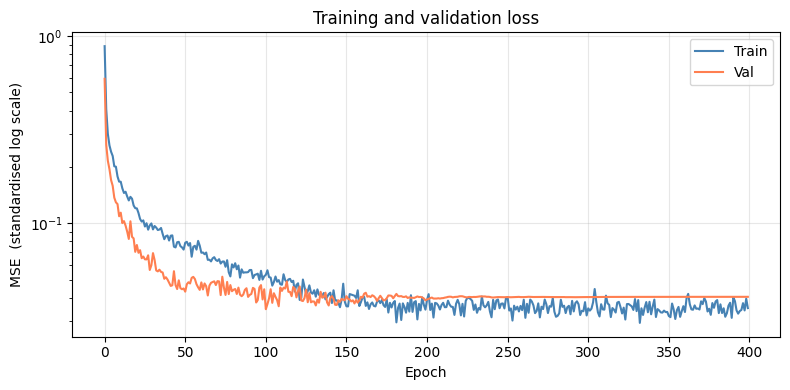

In [10]:
# ── 4.3  Loss curves  (D5.2) ─────────────────────────────────────────────────
#
# What to look for:
#   Both curves decrease steadily   → model is learning
#   Val diverges from train         → overfitting
#   Both flat from early on         → underfitting or bad learning rate
#   Val lower than train            → strong dropout or small val set (not a problem)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(history['train'], label='Train', color='steelblue')
ax.semilogy(history['val'],   label='Val',   color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE  (standardised log scale)')
ax.set_title('Training and validation loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

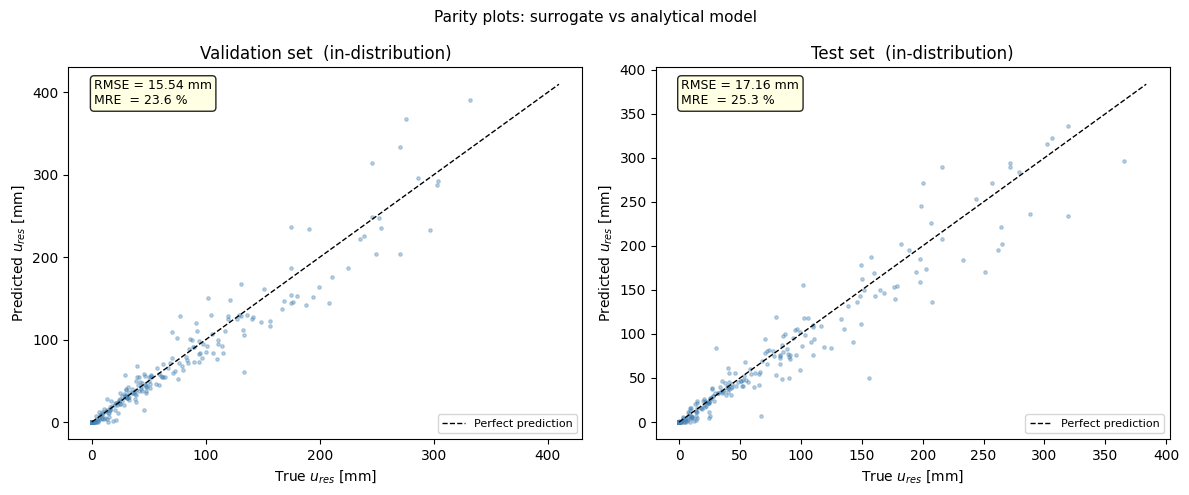

Validation  RMSE=15.545 mm   MRE=23.6%
Test        RMSE=17.158 mm   MRE=25.3%

Both sets are drawn from the same distribution → results should be similar.
For a harder test on a different loading regime, see Experiment D.


In [11]:
# ── 4.4  Parity plots and engineering metrics ─────────────────────────────────

def predict_mm(loader: DataLoader):
    """Return (y_true_mm, y_pred_mm) in physical units [mm]."""
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for xb, yb in loader:
            pred = model(xb.to(DEVICE)).cpu().numpy()
            # Inverse pipeline: unscale → 10^(·) → metres → mm
            yp.append((10 ** unscale_y(pred)   - EPS) * 1e3)
            yt.append((10 ** unscale_y(yb.numpy()) - EPS) * 1e3)
    return np.concatenate(yt).flatten(), np.concatenate(yp).flatten()


def rmse(t, p):  return np.sqrt(np.mean((t - p)**2))
def mre(t, p):
    # Exclude near-zero true values to avoid division blow-up
    mask = np.abs(t) > 1.0   # threshold: 1 mm
    return (np.abs(t[mask] - p[mask]) / np.abs(t[mask])).mean() * 100


yt_val, yp_val = predict_mm(loader_val)
yt_te,  yp_te  = predict_mm(loader_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, yt, yp, title in zip(
        axes,
        [yt_val,  yt_te],
        [yp_val,  yp_te],
        ['Validation set  (in-distribution)',
         'Test set  (in-distribution)']):

    vmax = max(yt.max(), yp.max()) * 1.05
    ax.scatter(yt, yp, s=6, alpha=0.35, color='steelblue')
    ax.plot([0, vmax], [0, vmax], 'k--', lw=1, label='Perfect prediction')
    ax.set_xlabel('True $u_{res}$ [mm]')
    ax.set_ylabel('Predicted $u_{res}$ [mm]')
    ax.set_title(title)
    ax.legend(fontsize=8)
    r, m = rmse(yt, yp), mre(yt, yp)
    ax.text(0.05, 0.90, f'RMSE = {r:.2f} mm\nMRE  = {m:.1f} %',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

plt.suptitle('Parity plots: surrogate vs analytical model', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Validation  RMSE={rmse(yt_val,yp_val):.3f} mm   MRE={mre(yt_val,yp_val):.1f}%")
print(f"Test        RMSE={rmse(yt_te, yp_te):.3f} mm   MRE={mre(yt_te, yp_te):.1f}%")
print()
print("Both sets are drawn from the same distribution → results should be similar.")
print("For a harder test on a different loading regime, see Experiment D.")

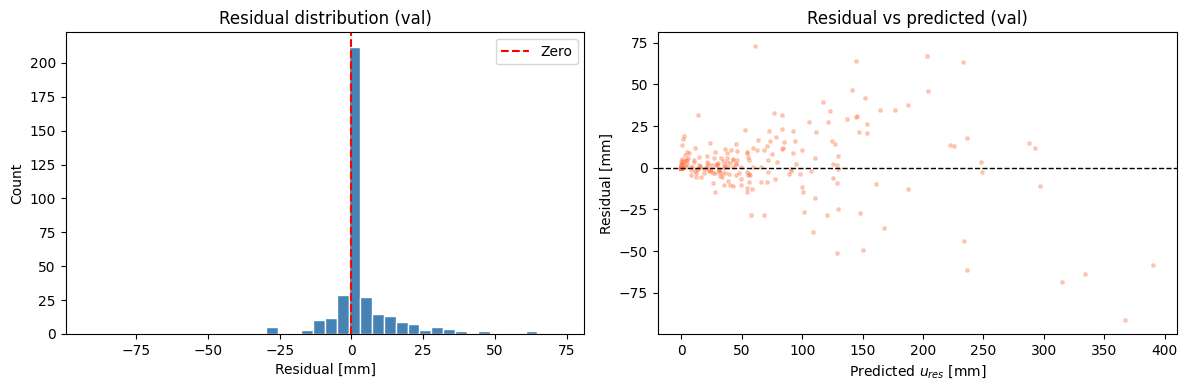

In [12]:
# ── 4.5  Residual analysis ────────────────────────────────────────────────────
#
# Residual = true - predicted.
# Good model: residuals centred on zero, no trend vs predicted value.
# Fan shape: error grows with prediction → consider log-scale target (already done).
# Systematic shift: model bias → investigate data or architecture.

res_val = yt_val - yp_val

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(res_val, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='Zero')
axes[0].set_xlabel('Residual [mm]')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual distribution (val)')
axes[0].legend()

axes[1].scatter(yp_val, res_val, s=6, alpha=0.35, color='coral')
axes[1].axhline(0, color='black', linestyle='--', lw=1)
axes[1].set_xlabel('Predicted $u_{res}$ [mm]')
axes[1].set_ylabel('Residual [mm]')
axes[1].set_title('Residual vs predicted (val)')

plt.tight_layout()
plt.show()

---
## 5 — Your turn

Three experiments, each with a concrete observable result.
Complete **at least two** before the Q&A.

### Experiment A — Deliberately introduce data leakage

Re-normalise the inputs using statistics computed on the **entire dataset** (train + val + test combined), instead of train only. Retrain the model from scratch. Compare validation and test errors before and after.

- Does the validation error look better?
- Does the test error look better or worse?
- What does this tell you about why leakage is dangerous in engineering applications?

> Connect to: **D1.6** (data leakage) and **D4.1** (normalisation).

In [ ]:
# ── Experiment A ──────────────────────────────────────────────────────────────
# Step 1: compute X_mean_leak, X_std_leak, y_mean_leak, y_std_leak
#         on ALL indices (idx_train + idx_val + idx_test combined)
# Step 2: rebuild loaders with leaked normalisation
# Step 3: instantiate a fresh SurrogateMLP, retrain for 400 epochs
# Step 4: print val and test RMSE side by side with the original model

# YOUR CODE HERE


### Experiment B — Architecture: underfitting vs overfitting

Train two additional models using the **same data and preprocessing** as the baseline:
- **Tiny model**: `hidden=[8, 8]`, no dropout
- **Large model**: `hidden=[512, 512, 256, 128]`, no dropout

Plot the loss curves of all three models on the same figure (use different colours).

- Which model underfits? How do you see it in the loss curve?
- Which model overfits? How do you see it?
- Does the large model outperform the baseline on the test set?

> Connect to: **D2.5** (learning ability), **D5.1** (bias–variance), **D5.2** (overfitting signature).

In [ ]:
# ── Experiment B ──────────────────────────────────────────────────────────────
# Hint: wrap the training loop in a helper function that takes a model
# and returns the loss history. Then plot all three on the same axes.

# YOUR CODE HERE


### Experiment C — Remove the log transform

Set `y_raw = data['u_res'].reshape(-1,1).astype(np.float32)` (raw metres, no log). Re-standardise on the training set only. Retrain the baseline architecture with MSE loss.

- How does the loss curve differ from the log-transformed version?
- Look at the parity plot. Where does the model struggle most — small or large deflections?
- Why? What does this tell you about the role of output transformations in engineering surrogates?

> Connect to: **D3.2** (loss functions), **D4.2** (engineering-friendly transformations).

In [ ]:
# ── Experiment C ──────────────────────────────────────────────────────────────
# Step 1: set y_raw = data['u_res'].reshape(-1,1).astype(np.float32)
# Step 2: standardise y_raw on train only (same split as before)
# Step 3: rebuild loaders, train fresh SurrogateMLP for 400 epochs
# Step 4: for the parity plot, the inverse transform is just unscale_y (no 10^)
#         and convert m → mm
# Step 5: compare RMSE and parity plot with the log-transformed model

# YOUR CODE HERE


### Experiment D — Regime-based split: a real extrapolation challenge

Rebuild the train/val/test split so that:
- **Train + Val**: cases with $t_d/T_n \geq 0.4$ (dynamic and quasi-static regime, sinusoidal DLF branch)
- **Test**: cases with $t_d/T_n < 0.4$ (impulsive regime, linear DLF branch)

Retrain the baseline model on this split. Then evaluate on the impulsive test set.

- How does the test RMSE compare to the random-split baseline?
- Look at the parity plot. Where does the model fail — small or large deflections?
- The DLF formula has a slope discontinuity at $t_d/T_n = 0.4$. Does the model pick this up or ignore it?
- What would you need to fix this — more data, a different architecture, or something else entirely?

> This is the situation you face in real engineering: the model is deployed on a loading condition it has never seen. Connect to: **D1.5** (split strategy), **D6.1** (OOD behaviour).

In [ ]:
# ── Experiment D ──────────────────────────────────────────────────────────────
# Step 1: build idx_train_D, idx_val_D, idx_test_D using td_Tn threshold 0.4
#         (80/20 split within dynamic cases; all impulsive cases → test)
# Step 2: refit normalisation on idx_train_D only
# Step 3: rebuild loaders, train fresh SurrogateMLP for 400 epochs
# Step 4: parity plot on the impulsive test set, report RMSE and MRE
# Step 5: compare with the random-split result from Section 4

# YOUR CODE HERE


---
## Summary

| Step | What | Why |
|------|------|-----|
| Dataset | SDOF blast model, 4 inputs, multiplicative noise | Physically grounded, interpretable |
| EDA | Distribution, scatter plots, sanity checks | Never skip |
| Split | By $t_d/T_n$ regime, not randomly | Tests real generalisation |
| Normalisation | Fit on train only, apply to all splits | Prevents leakage |
| Log transform | Compress three-decade output range | Stabilises gradients, improves small-deflection accuracy |
| MLP | $4\to64\to64\to32\to1$, ReLU, Dropout(0.1) | Small, explicit, interpretable |
| Optimiser | AdamW + ReduceLROnPlateau | Robust default for surrogates |
| Diagnostics | Loss curves, parity plots, residuals | Run all three, every time |
| OOD test | Impulsive regime held out | Honest evaluation of extrapolation ability |

---

> **Take-away:** the engineering decisions — split strategy, target transform, normalisation discipline — contribute more to surrogate quality than architecture choices. A clean pipeline with a small MLP outperforms a fancy architecture on a dirty one.